Initial Data Snapshot:
   Patient_ID            Name  Age  Gender  Address     Allergens  \
0       P001   Amit Patel C.   58  Female   Jaipur           NaN   
1       P002  Arjun Mehta A.   28    Male   Mumbai        Pollen   
2       P003  Simran Kaur D.   30  Female     Pune        Pollen   
3       P004  Neha Sharma D.   74  Female   Jaipur  Food Allergy   
4       P005  Kavita Nair C.   10    Male  Chennai  Food Allergy   

  Chronic_Conditions Family_History Doctor_Name    Specialization  ...  \
0      Heart Disease         Asthma    Dr. Nair         Neurology  ...   
1      Heart Disease   Hypertension    Dr. Iyer         Neurology  ...   
2           Diabetes  Heart Disease     Dr. Das       Orthopedics  ...   
3       Hypertension         Asthma  Dr. Sharma        Cardiology  ...   
4                NaN   Hypertension  Dr. Kapoor  General Medicine  ...   

  Risk_Indicators Doctor_ID      Department Patient_Condition_Severity  \
0         Old Age      D001  Neuro Sciences     

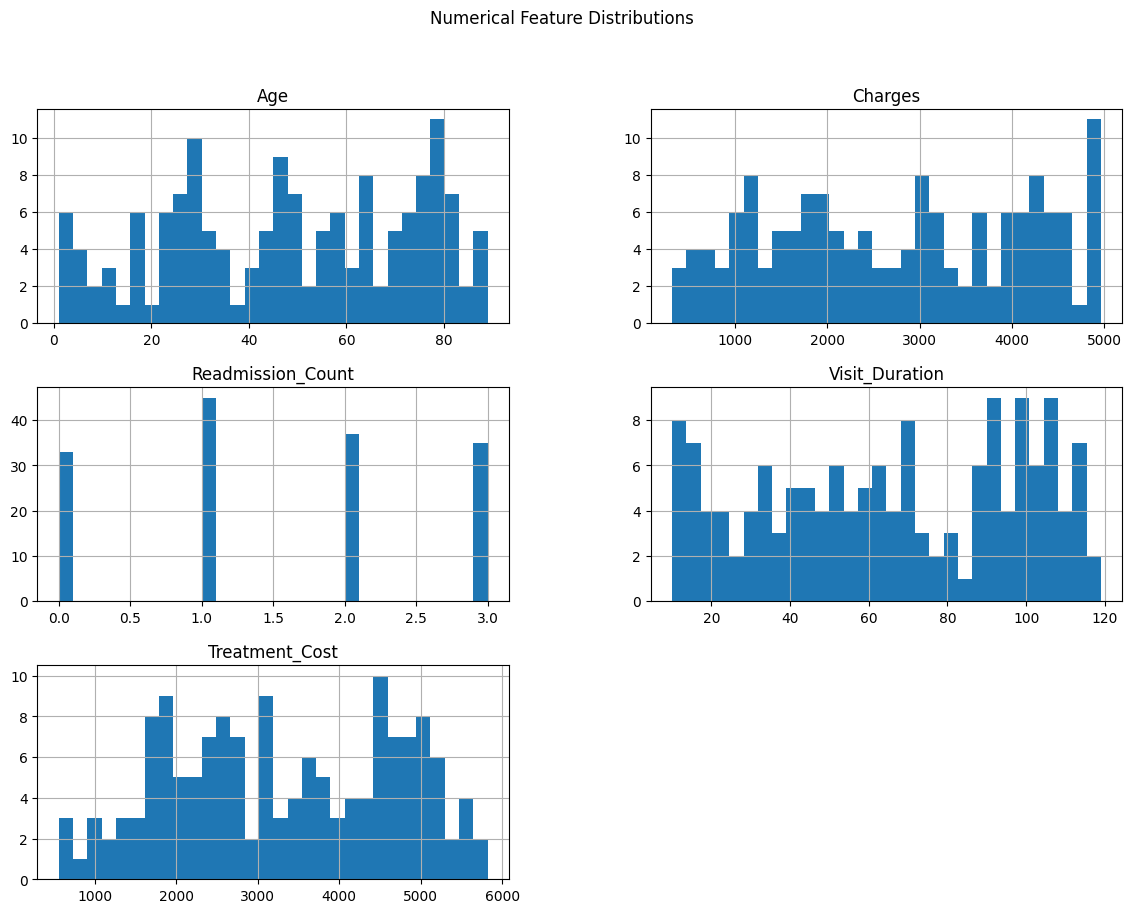

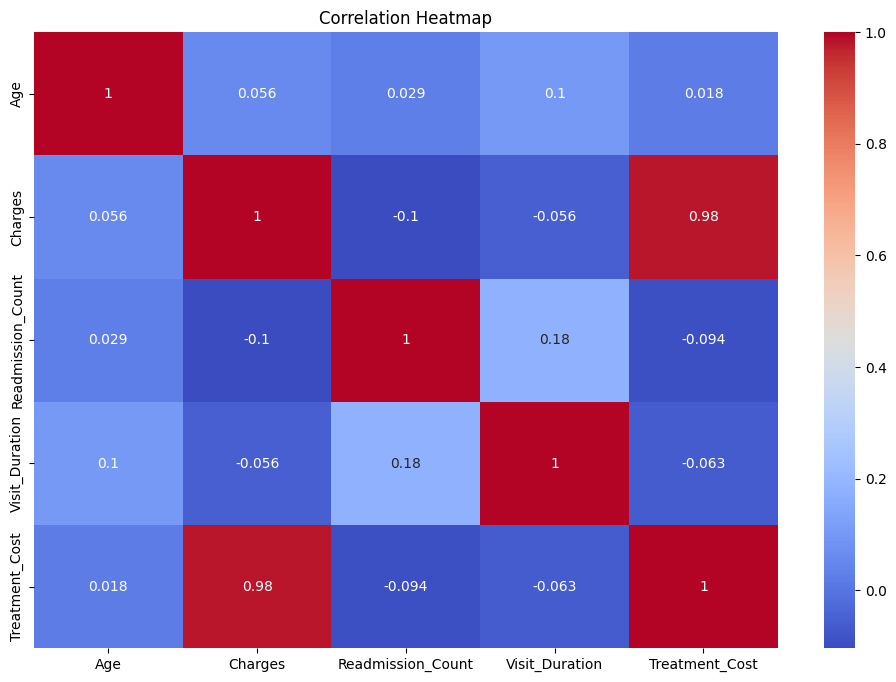

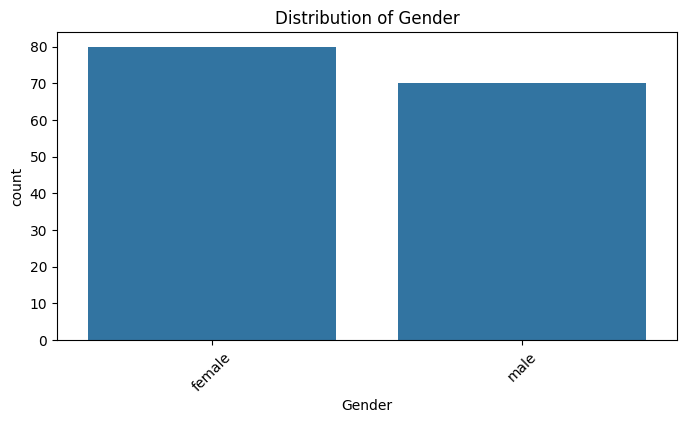

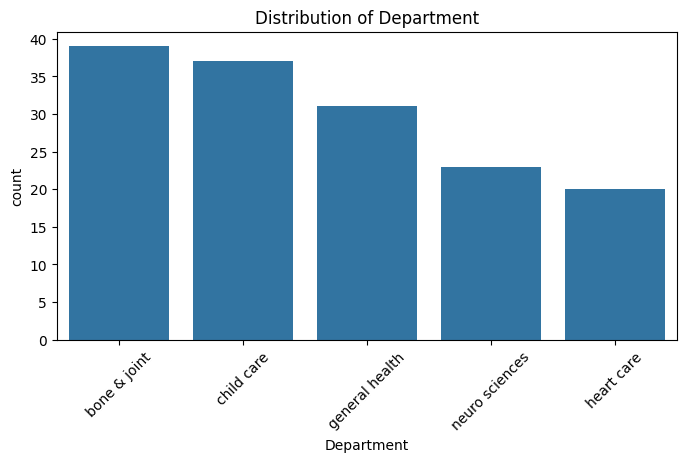

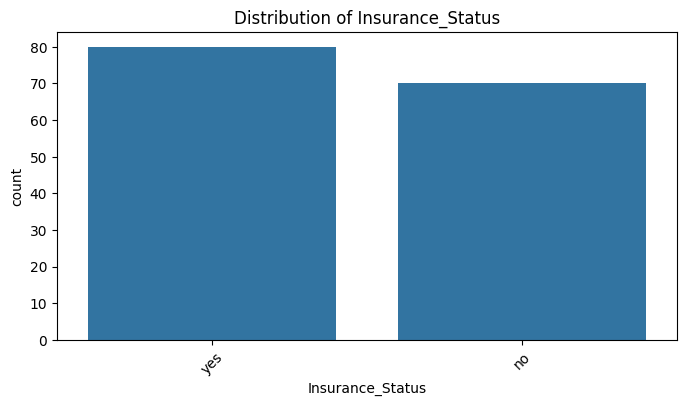

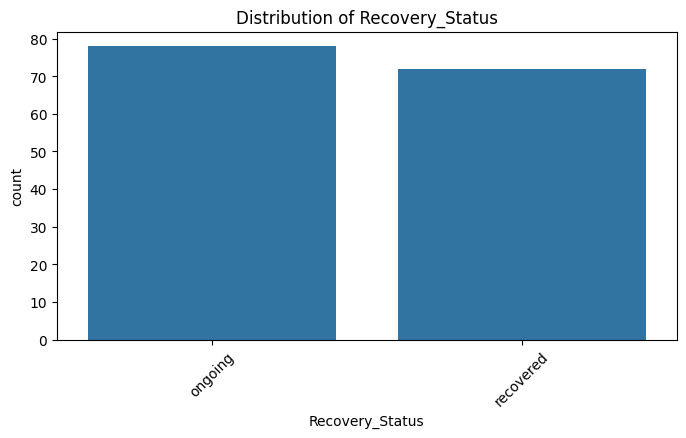

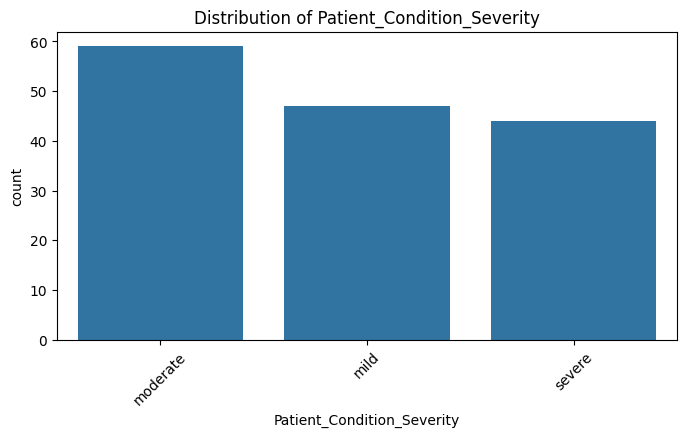


Recovery Rate by Gender:
 Gender  Recovery_Status
female  recovered          0.525000
        ongoing            0.475000
male    ongoing            0.571429
        recovered          0.428571
Name: proportion, dtype: float64

Recovery Rate by Department:
 Department      Recovery_Status
bone & joint    recovered          0.564103
                ongoing            0.435897
child care      ongoing            0.567568
                recovered          0.432432
general health  ongoing            0.516129
                recovered          0.483871
heart care      recovered          0.600000
                ongoing            0.400000
neuro sciences  ongoing            0.695652
                recovered          0.304348
Name: proportion, dtype: float64

Final Processed Shape: (150, 39)

Final Columns:
 ['Patient_ID', 'Age', 'Allergens', 'Chronic_Conditions', 'Family_History', 'Doctor_Name', 'Specialization', 'Appointment_Date', 'Time', 'Symptoms', 'Diagnosis', 'Treatment', 'Follow_Up'

In [8]:
# ================================
# Hospital ER System - Preprocessing & EDA
# ================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
df = pd.read_csv("Hospital Mangement System.csv")

# 3. Initial Exploration
print("Initial Data Snapshot:\n", df.head())
print("\nData Info:")
df.info()
print("\nData Shape:", df.shape)
print("\nSummary Statistics (all columns):\n", df.describe(include='all'))

# 4. Missing Values & Duplicates
print("\nMissing Values per column:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)

# 5. Data Cleaning
# Fill numerical columns with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Charges'] = df['Charges'].fillna(df['Charges'].median())
df['Readmission_Count'] = df['Readmission_Count'].fillna(df['Readmission_Count'].median())
df['Visit_Duration'] = df['Visit_Duration'].fillna(df['Visit_Duration'].median())
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

# Fill categorical/text columns with 'Unknown' and normalize
df['Gender'] = df['Gender'].fillna("Unknown").str.strip().str.lower()
df['Department'] = df['Department'].fillna("Unknown").str.strip().str.lower()
df['Insurance_Status'] = df['Insurance_Status'].fillna("Unknown").str.strip().str.lower()
df['Recovery_Status'] = df['Recovery_Status'].fillna("Unknown").str.strip().str.lower()
df['Patient_Condition_Severity'] = df['Patient_Condition_Severity'].fillna("Unknown").str.strip().str.lower()

# 6. Drop Irrelevant Columns (direct, no conditions)
df.drop(columns=['Name', 'Address'], inplace=True)

# 7. Feature Engineering
# Age Group Binning
df['age_group'] = pd.cut(df['Age'],
                         bins=[0, 18, 35, 50, 65, 120],
                         labels=['child', 'young_adult', 'adult', 'senior', 'elderly'],
                         right=True,
                         include_lowest=True)

# Cost per Day
df['cost_per_day'] = df['Treatment_Cost'] / df['Visit_Duration'].replace(0, np.nan)

# Chronic Condition Flag
df['chronic_flag'] = df['Chronic_Conditions'].apply(lambda x: 0 if x == 'none' else 1)

# 8. Outlier Detection (IQR Method)
for col in ['Charges', 'Treatment_Cost', 'Visit_Duration']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers detected | bounds=({lower:.2f}, {upper:.2f})")

# 9. Encoding Categorical Variables
df_encoded = pd.get_dummies(df,
                            columns=['Gender', 'Department', 'Insurance_Status',
                                     'Recovery_Status', 'Patient_Condition_Severity'],
                            drop_first=True)

# 10. Exploratory Data Analysis (EDA)
# Histograms for numerical columns
df[['Age', 'Charges', 'Readmission_Count', 'Visit_Duration', 'Treatment_Cost']].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[['Age', 'Charges', 'Readmission_Count', 'Visit_Duration', 'Treatment_Cost']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Countplots for categorical features
for col in ['Gender', 'Department', 'Insurance_Status', 'Recovery_Status', 'Patient_Condition_Severity']:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# 11. Target Variable Analysis
print("\nRecovery Rate by Gender:\n", df.groupby("Gender")["Recovery_Status"].value_counts(normalize=True))
print("\nRecovery Rate by Department:\n", df.groupby("Department")["Recovery_Status"].value_counts(normalize=True))

# 12. Final Check
print("\nFinal Processed Shape:", df_encoded.shape)
print("\nFinal Columns:\n", df_encoded.columns.tolist())


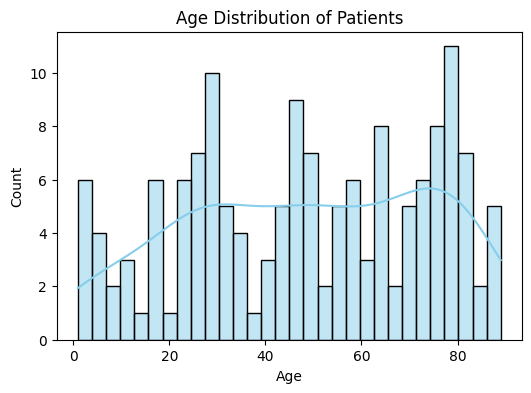

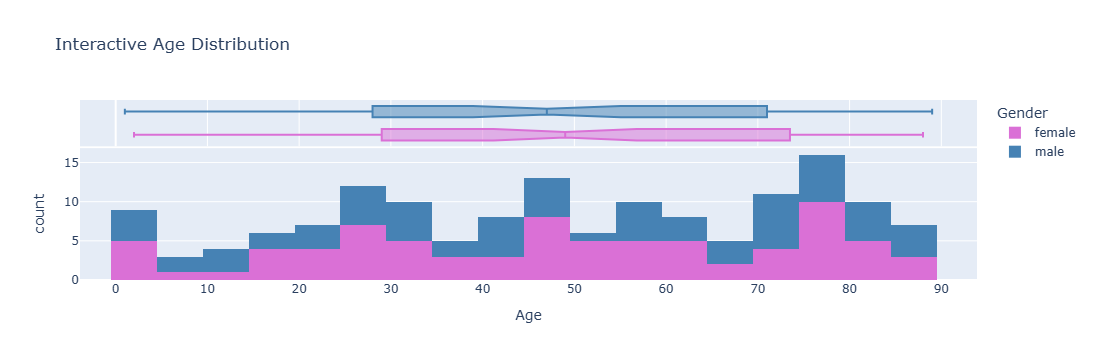

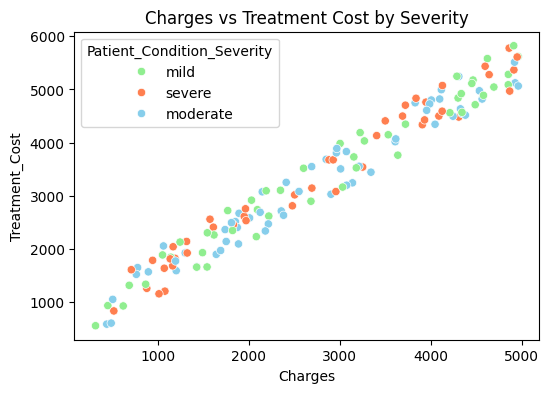

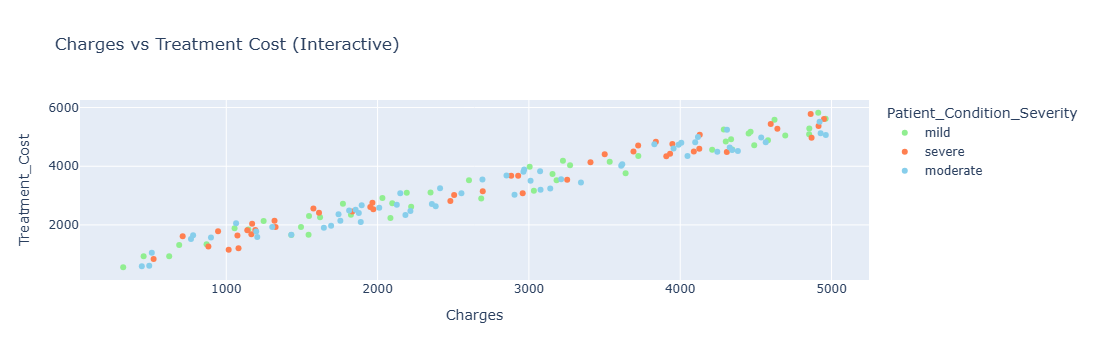

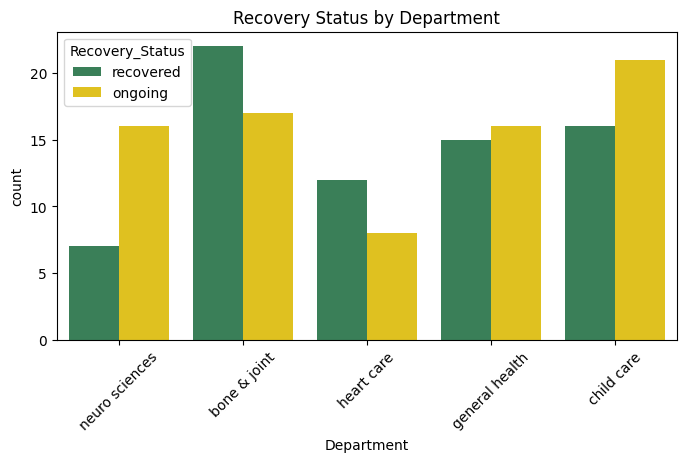

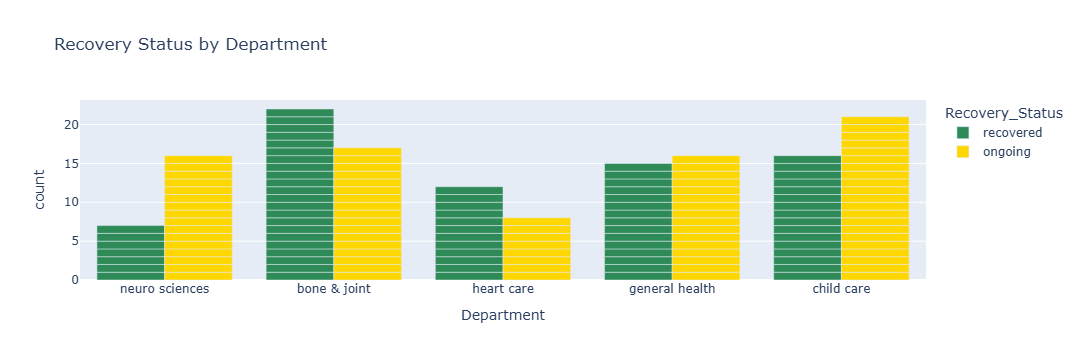

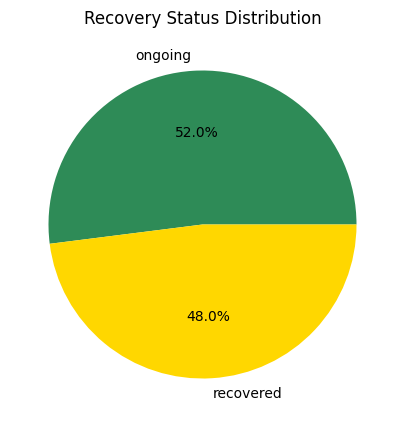

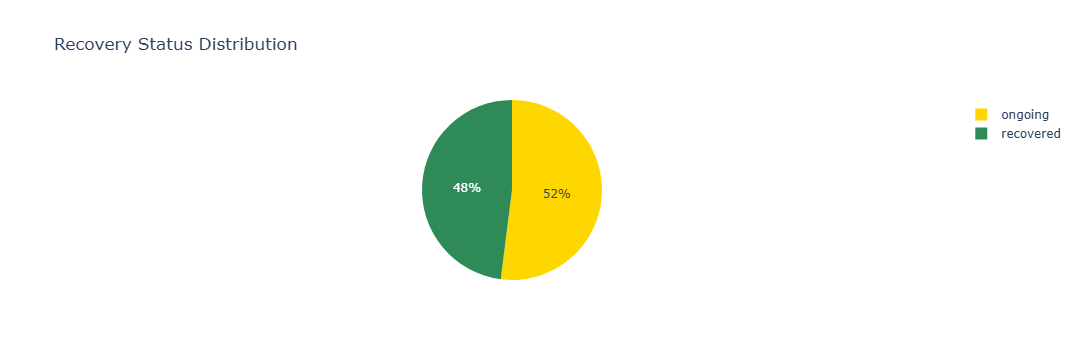

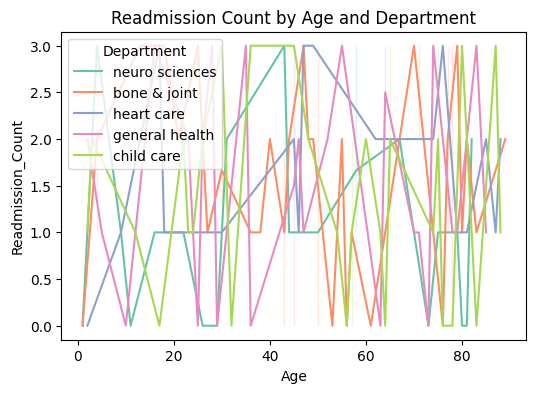

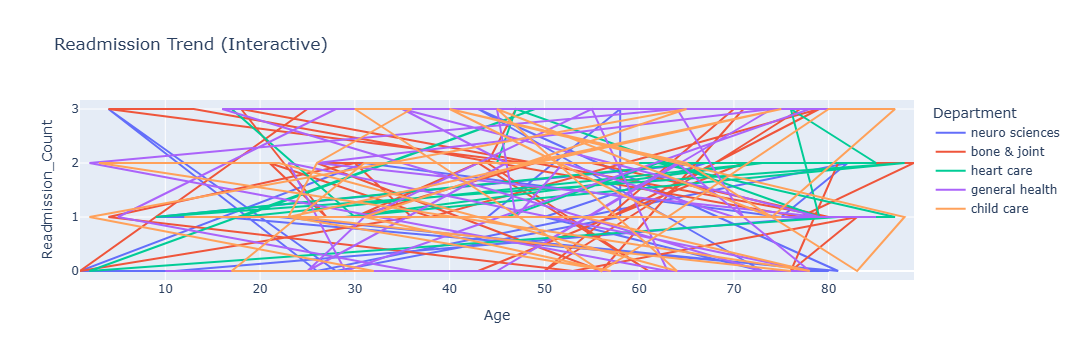

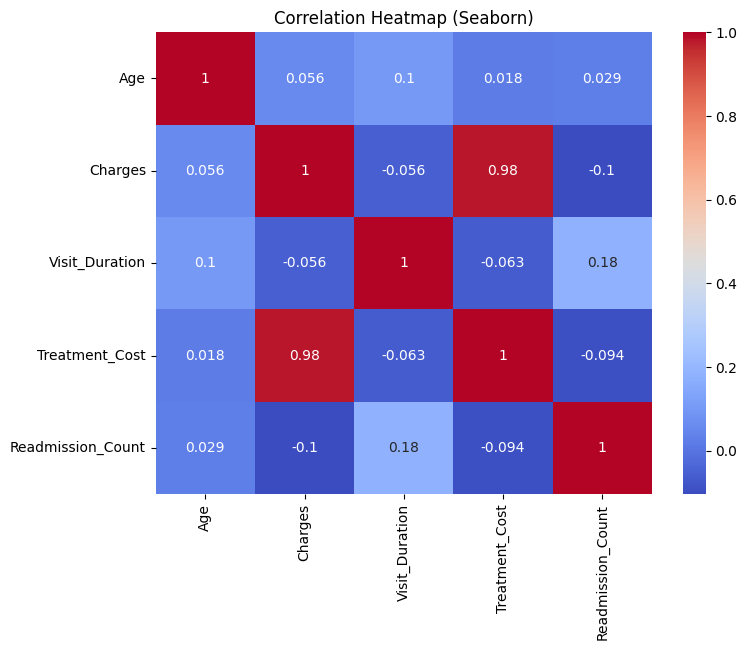

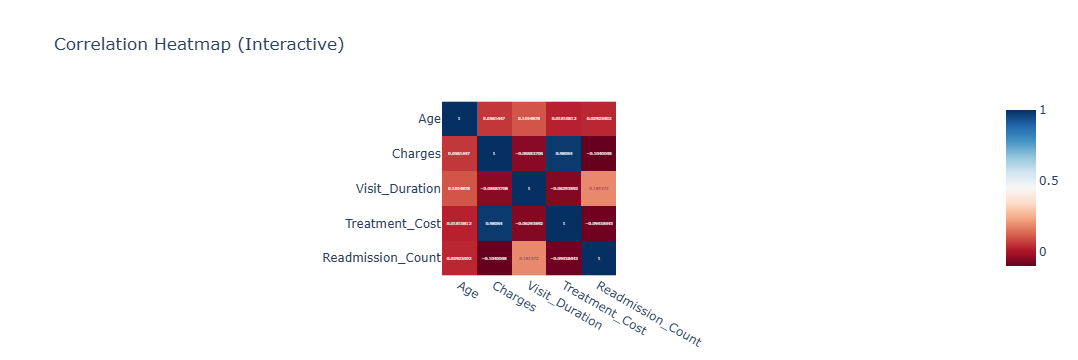

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# -------------------------------
# Age Distribution
# -------------------------------
plt.figure(figsize=(6,4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

fig_age = px.histogram(df, x="Age", nbins=30, color="Gender",
                       color_discrete_map={"male":"steelblue","female":"orchid"},
                       marginal="box", title="Interactive Age Distribution")
fig_age.show()

# -------------------------------
# Charges vs Treatment Cost
# -------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Charges", y="Treatment_Cost",
                hue="Patient_Condition_Severity",
                palette={"mild":"lightgreen","moderate":"skyblue","severe":"coral"})
plt.title("Charges vs Treatment Cost by Severity")
plt.show()

fig_cost = px.scatter(df, x="Charges", y="Treatment_Cost",
                      color="Patient_Condition_Severity",
                      color_discrete_map={"mild":"lightgreen","moderate":"skyblue","severe":"coral"},
                      hover_data=["Gender","Department","Recovery_Status"],
                      title="Charges vs Treatment Cost (Interactive)")
fig_cost.show()

# -------------------------------
# Recovery Status by Department
# -------------------------------
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Department", hue="Recovery_Status",
              palette={"recovered":"seagreen","ongoing":"gold","unknown":"gray"})
plt.title("Recovery Status by Department")
plt.xticks(rotation=45)
plt.show()

fig_recovery = px.bar(df, x="Department", color="Recovery_Status",
                      color_discrete_map={"recovered":"seagreen","ongoing":"gold","unknown":"gray"},
                      title="Recovery Status by Department", barmode="group")
fig_recovery.show()

# -------------------------------
# Recovery Status Distribution
# -------------------------------
plt.figure(figsize=(5,5))
df['Recovery_Status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['seagreen','gold','gray'])
plt.title("Recovery Status Distribution")
plt.ylabel("")
plt.show()

fig_pie = px.pie(df, names="Recovery_Status",
                 color="Recovery_Status",
                 color_discrete_map={"recovered":"seagreen","ongoing":"gold","unknown":"gray"},
                 title="Recovery Status Distribution")
fig_pie.show()

# -------------------------------
# Readmission Trend by Age
# -------------------------------
plt.figure(figsize=(6,4))
sns.lineplot(data=df, x="Age", y="Readmission_Count", hue="Department", palette="Set2")
plt.title("Readmission Count by Age and Department")
plt.show()

fig_readmit = px.line(df, x="Age", y="Readmission_Count",
                      color="Department", title="Readmission Trend (Interactive)")
fig_readmit.show()

# -------------------------------
# Correlation Heatmap
# -------------------------------
num_cols = ["Age","Charges","Visit_Duration","Treatment_Cost","Readmission_Count"]
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Seaborn)")
plt.show()

fig_heatmap = px.imshow(df[num_cols].corr(), text_auto=True,
                        color_continuous_scale="RdBu", title="Correlation Heatmap (Interactive)")
fig_heatmap.show()


In [ ]:
# Hospital ER EDA & Visualization

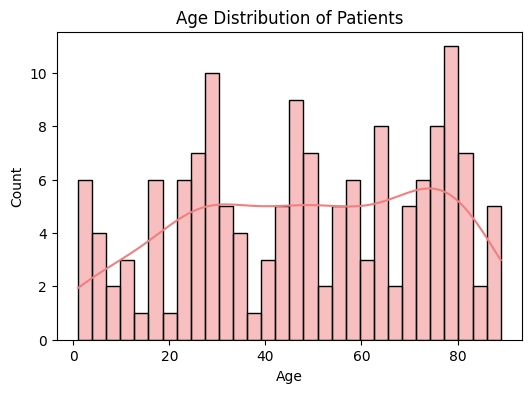

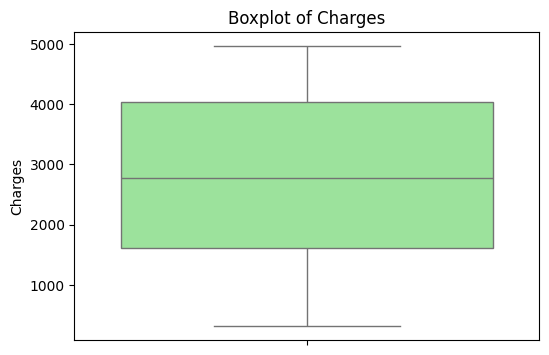

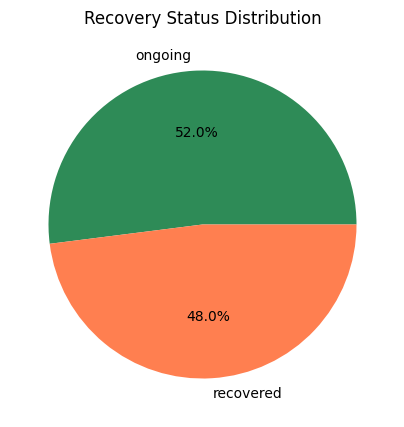

In [21]:
# 1. Univariate Analysis
# Explore single variables to understand distributions.

# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='lightcoral', edgecolor='black')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Charges Distribution
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Charges'], color='lightgreen')
plt.title("Boxplot of Charges")
plt.show()

# Recovery Status Distribution (Pie)
plt.figure(figsize=(5,5))
df['Recovery_Status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['seagreen','coral','pink'])
plt.title("Recovery Status Distribution")
plt.ylabel("")
plt.show()



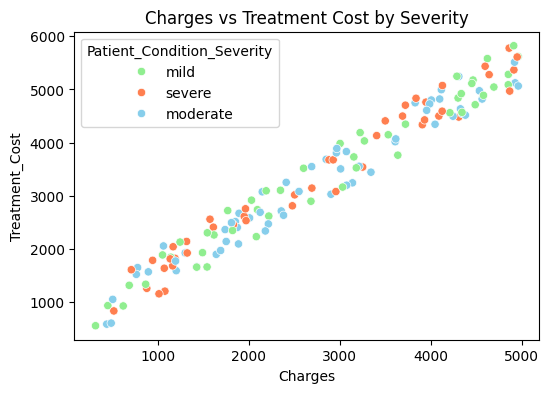

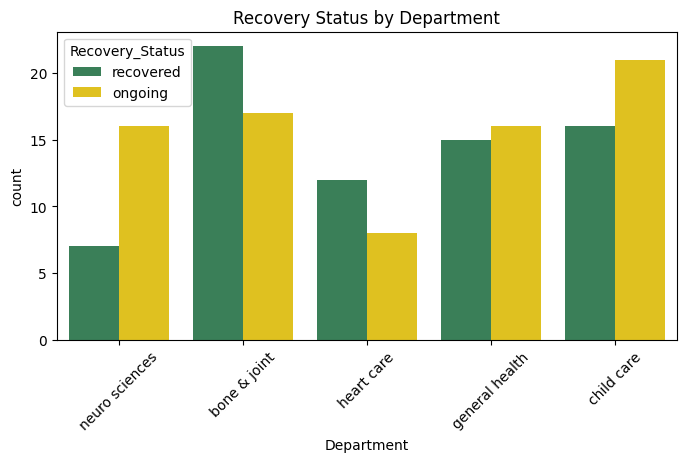

C:\Users\Tanushree Chauhan\AppData\Local\Temp\ipykernel_63084\4288119794.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




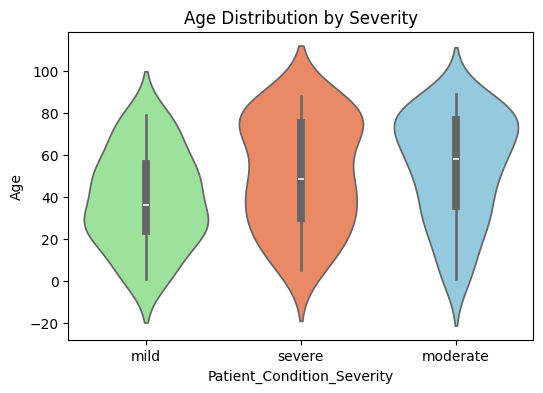

In [22]:
# 2. Bivariate Analysis
# Compare two variables to see relationships.
# Charges vs Treatment Cost by Severity
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Charges", y="Treatment_Cost",
                hue="Patient_Condition_Severity",
                palette={"mild":"lightgreen","moderate":"skyblue","severe":"coral"})
plt.title("Charges vs Treatment Cost by Severity")
plt.show()

# Recovery Status by Department
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Department", hue="Recovery_Status",
              palette={"recovered":"seagreen","ongoing":"gold","unknown":"gray"})
plt.title("Recovery Status by Department")
plt.xticks(rotation=45)
plt.show()

# Age Distribution by Severity (Violin)
plt.figure(figsize=(6,4))
sns.violinplot(x="Patient_Condition_Severity", y="Age", data=df,
               palette={"mild":"lightgreen","moderate":"skyblue","severe":"coral"})
plt.title("Age Distribution by Severity")
plt.show()

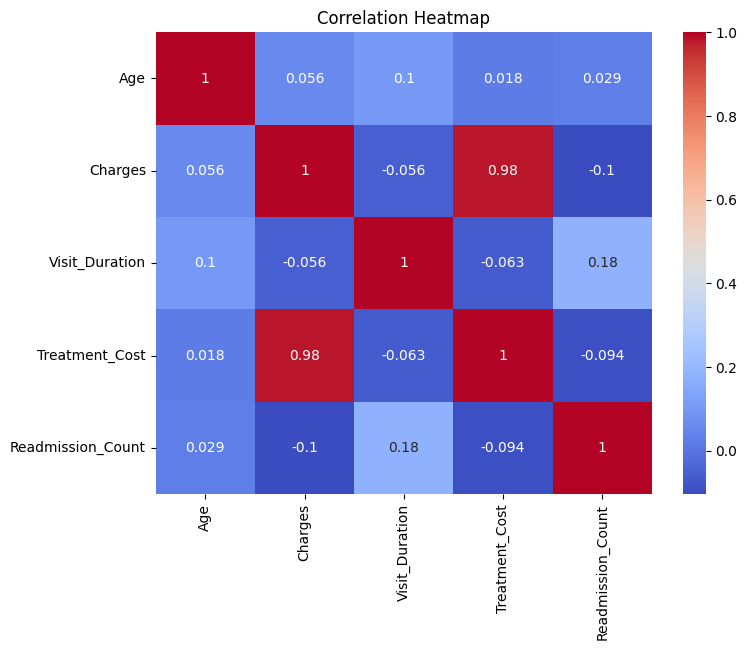

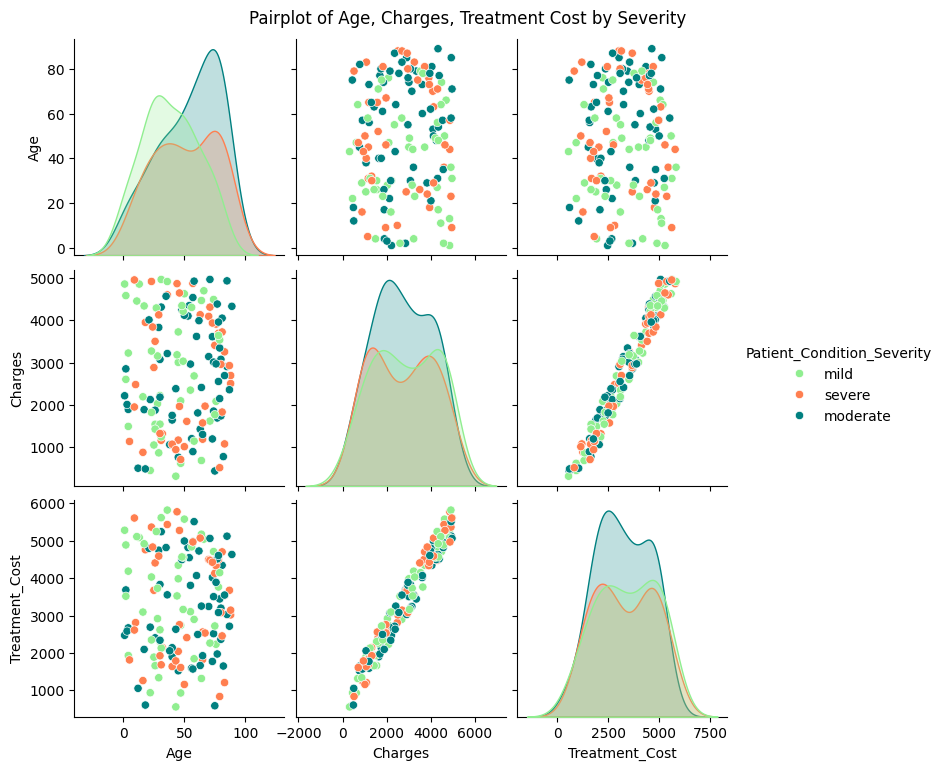

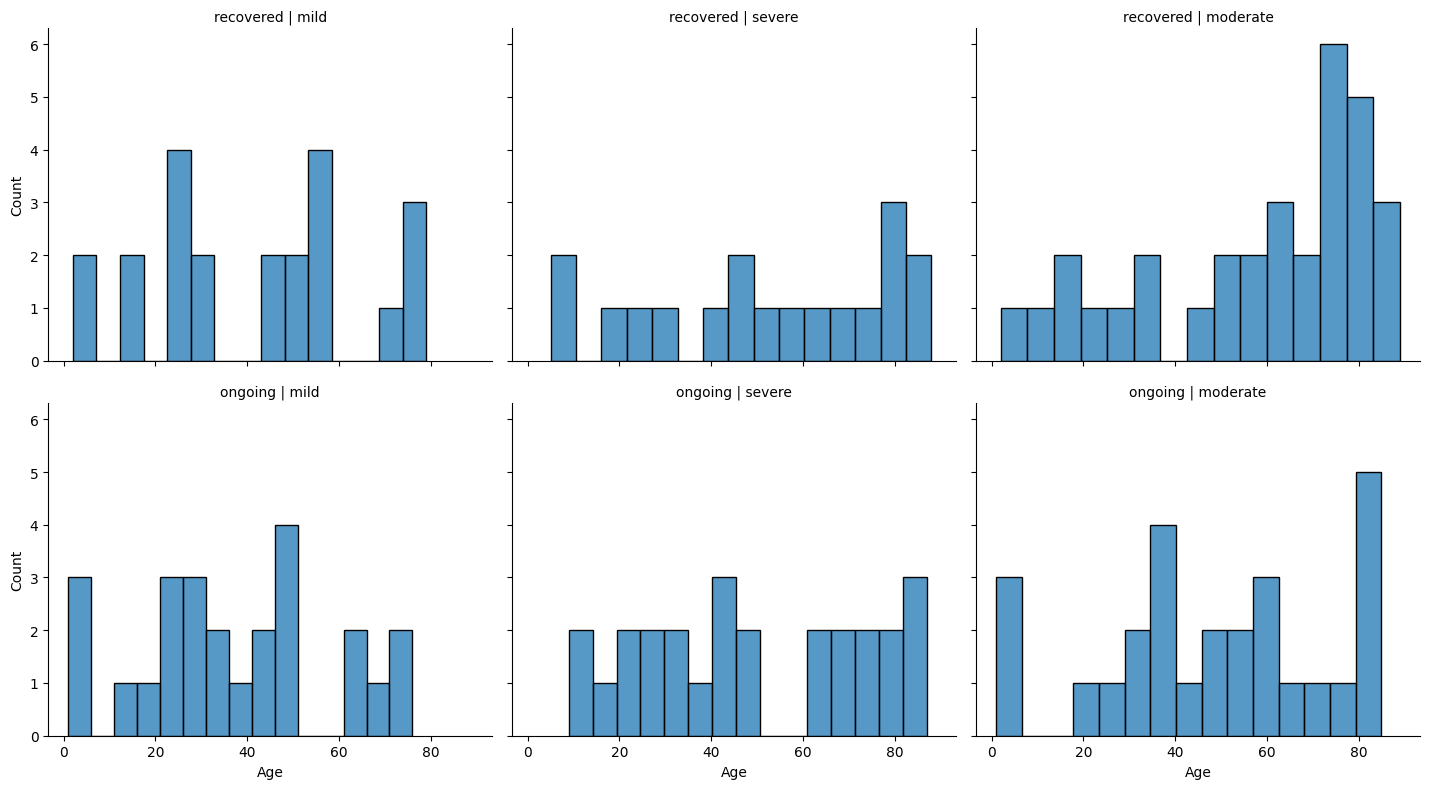

In [24]:
# 3. Multivariate Analysis
# Look at multiple variables together.

# Correlation Heatmap
num_cols = ["Age","Charges","Visit_Duration","Treatment_Cost","Readmission_Count"]
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df, vars=["Age","Charges","Treatment_Cost"], hue="Patient_Condition_Severity",
             palette={"mild":"lightgreen","moderate":"teal","severe":"coral"})
plt.suptitle("Pairplot of Age, Charges, Treatment Cost by Severity", y=1.02)
plt.show()

# FacetGrid: Age distribution split by Severity & Recovery
g = sns.FacetGrid(df, col="Patient_Condition_Severity", row="Recovery_Status",
                  height=4, aspect=1.2,
                  palette={"recovered":"seagreen","ongoing":"gold","unknown":"gray"})
g.map_dataframe(sns.histplot, x="Age", bins=15, kde=False)
g.set_axis_labels("Age", "Count")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.show()



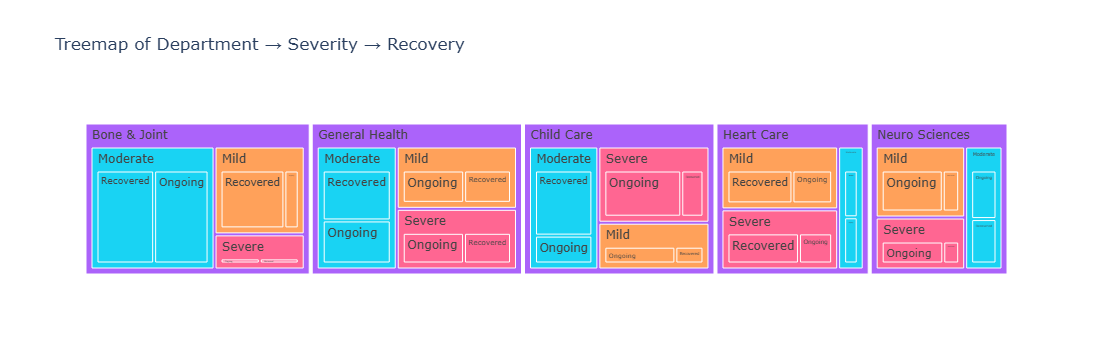

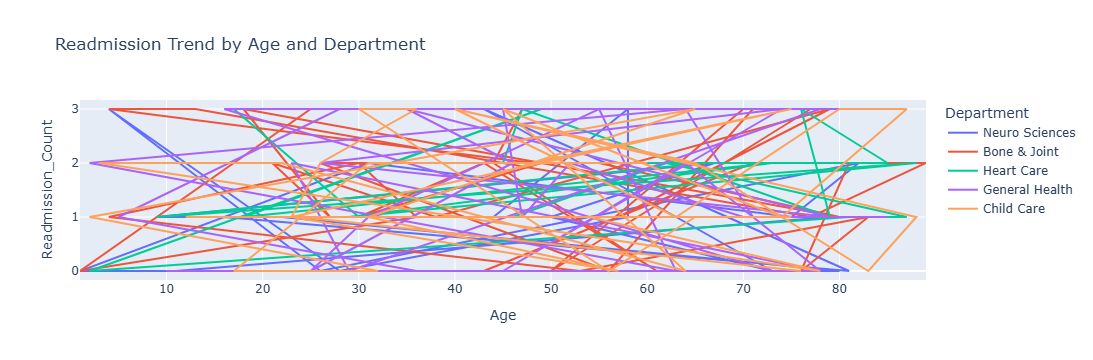

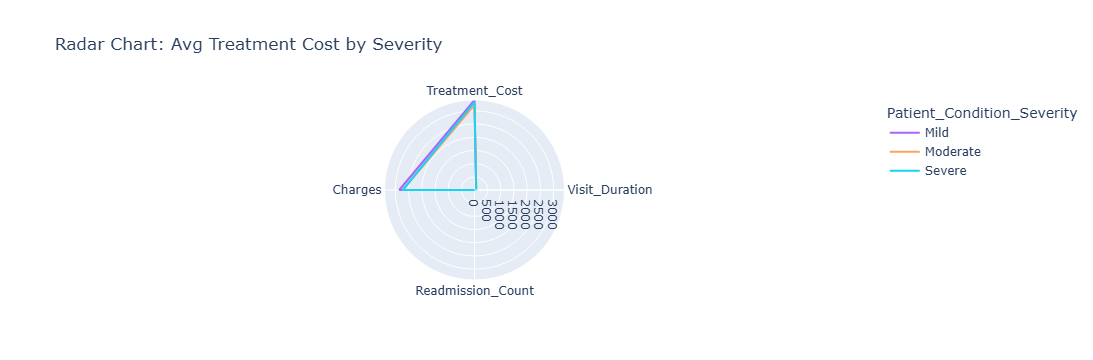

C:\Users\Tanushree Chauhan\AppData\Local\Temp\ipykernel_63084\2892284599.py:30: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



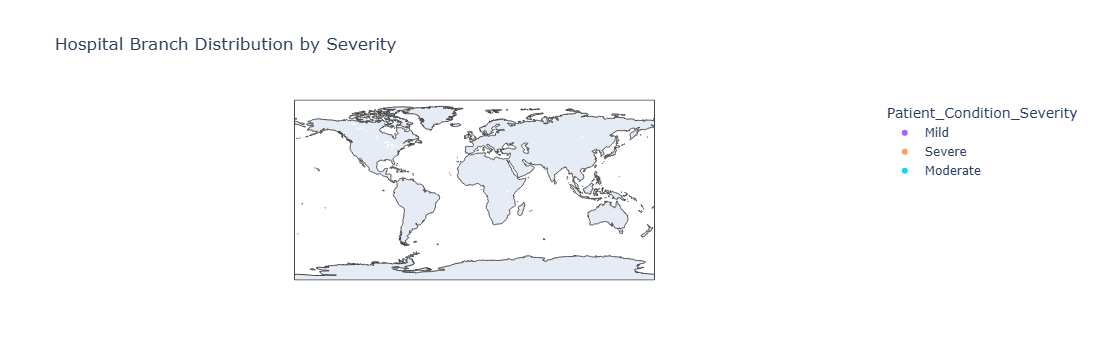

In [69]:
# 4. Advanced Visualizations (Plotly)

import plotly.express as px

# Treemap: Department → Severity → Recovery
fig_treemap = px.treemap(df, path=['Department','Patient_Condition_Severity','Recovery_Status'],
                         values='Charges',
                         color='Patient_Condition_Severity',
                         color_discrete_map={"mild":"lightgreen","moderate":"skyblue","severe":"coral"},
                         title="Treemap of Department → Severity → Recovery")
fig_treemap.show()

# Line Plot (Readmission Trend)
fig_line = px.line(df, x="Age", y="Readmission_Count", color="Department",
                   title="Readmission Trend by Age and Department")
fig_line.show()

# Radar Chart: Severity groups comparing averages
summary_long = summary.melt(id_vars="Patient_Condition_Severity",
                            value_vars=["Treatment_Cost","Visit_Duration","Readmission_Count","Charges"],
                            var_name="Metric", value_name="Average")

fig_radar = px.line_polar(summary_long, r="Average", theta="Metric", color="Patient_Condition_Severity", line_close=True,
                          color_discrete_map={"mild":"lightgreen","moderate":"skyblue","severe":"coral"},
                          title="Radar Chart: Avg Treatment Cost by Severity")
fig_radar.show()


# Geo Scatter: Hospital Branches
fig_geo = px.scatter_geo(df, locations="Hospital_Branch", locationmode="country names",
                         color="Patient_Condition_Severity",
                         color_discrete_map={"mild":"lightgreen","moderate":"skyblue","severe":"coral"},
                         title="Hospital Branch Distribution by Severity")
fig_geo.show()



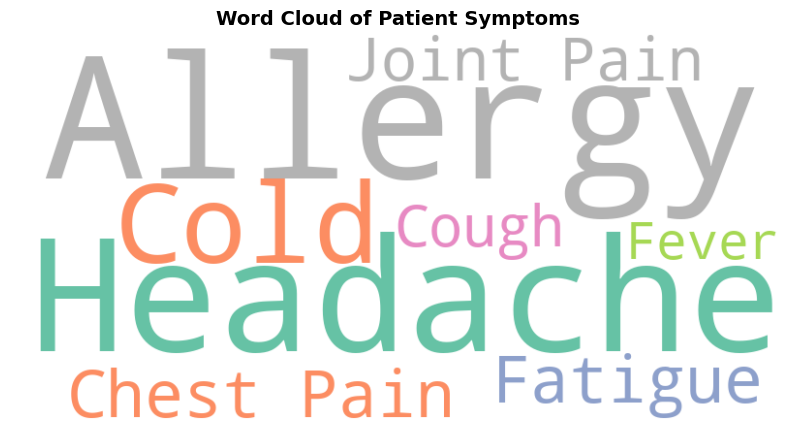

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Example: Word Cloud for Symptoms
text = " ".join(df['Symptoms'].dropna().astype(str))

wc = WordCloud(width=800, height=400,
               background_color='white',
               colormap='Set2',   # pastel colors
               max_words=100).generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Patient Symptoms", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
#Statistical Data Analysis

Extended Summary Statistics:
                  Age       Charges  Treatment_Cost  Visit_Duration  \
count     150.000000  1.500000e+02    1.500000e+02      150.000000   
mean       48.426667  2.762073e+03    3.312687e+03       65.853333   
std        25.195703  1.364994e+03    1.384746e+03       32.675420   
min         1.000000  3.190000e+02    5.570000e+02       10.000000   
25%        28.250000  1.614750e+03    2.141250e+03       39.250000   
50%        48.500000  2.773500e+03    3.181500e+03       66.000000   
75%        73.000000  4.037750e+03    4.567250e+03       97.000000   
max        89.000000  4.962000e+03    5.822000e+03      119.000000   
variance  634.823445  1.863210e+06    1.917520e+06     1067.683043   
IQR        44.750000  2.423000e+03    2.426000e+03       57.750000   
mode       30.000000  1.430000e+03    3.676000e+03       16.000000   

          Readmission_Count  
count            150.000000  
mean               1.493333  
std                1.079067  
min      

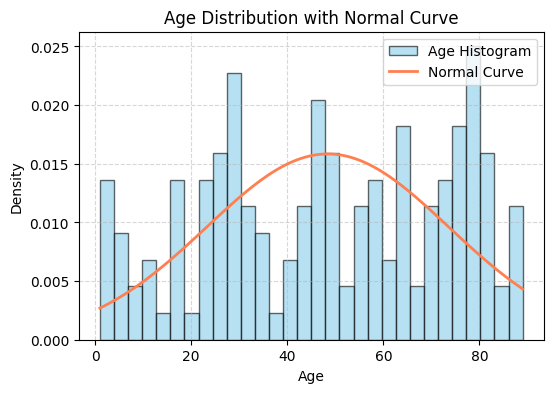

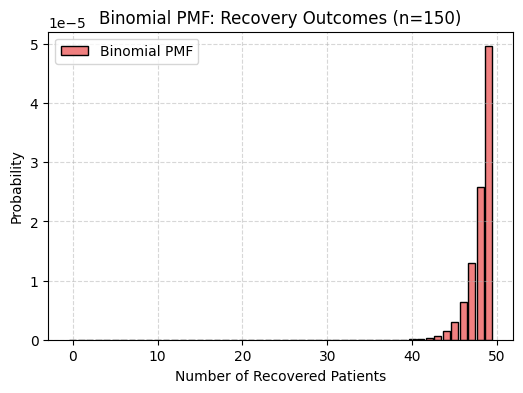

P(X ≤ 60 recovered out of 150): 0.0297



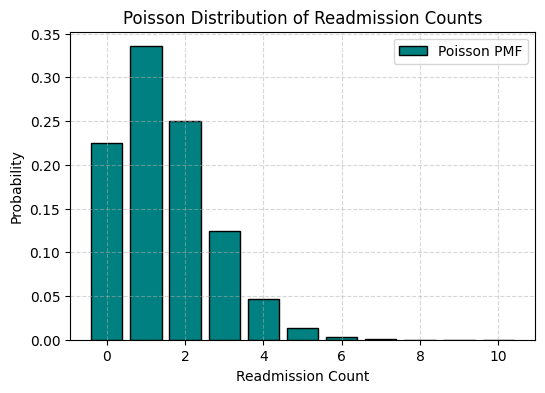

In [45]:
# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom, poisson, chi2_contingency, ttest_ind, f_oneway

# Load dataset
df = pd.read_csv("Hospital Mangement System.csv")

# -------------------------------
# 2. Measures of Central Tendency & Dispersion
# -------------------------------
cols = ['Age','Charges','Treatment_Cost','Visit_Duration','Readmission_Count']

# Basic summary
summary = df[cols].describe()

# Variance
variance = df[cols].var()
variance.name = "variance"

# Interquartile Range (IQR)
iqr = df[cols].quantile(0.75) - df[cols].quantile(0.25)
iqr.name = "IQR"

# Mode
mode = df[cols].mode().iloc[0]
mode.name = "mode"

# Combine into one table
extended_summary = pd.concat([summary, variance.to_frame().T, iqr.to_frame().T, mode.to_frame().T])
print("Extended Summary Statistics:\n", extended_summary)

# -------------------------------
# 3. Probability Distributions
# -------------------------------

# Normal Distribution (Age)
age_mean = df['Age'].mean()
age_std = df['Age'].std()
x = np.linspace(df['Age'].min(), df['Age'].max(), 100)
y = norm.pdf(x, age_mean, age_std)

plt.figure(figsize=(6,4))
plt.hist(df['Age'].dropna(), bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Age Histogram')
plt.plot(x, y, color='coral', linewidth=2, label='Normal Curve')
plt.title("Age Distribution with Normal Curve")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Binomial Distribution (Recovery_Status)
n = len(df)   # total patients = 150
p = (df['Recovery_Status'].str.lower() == 'recovered').mean()
x_binom = np.arange(0, n+1)
pmf_binom = binom.pmf(x_binom, n, p)

plt.figure(figsize=(6,4))
plt.bar(x_binom[:50], pmf_binom[:50], color='lightcoral', edgecolor='black', label='Binomial PMF')
plt.title(f"Binomial PMF: Recovery Outcomes (n={n})")
plt.xlabel("Number of Recovered Patients")   
plt.ylabel("Probability")                   
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Example probability
prob_at_most_60 = binom.cdf(60, n, p)
print(f"P(X ≤ 60 recovered out of {n}): {prob_at_most_60:.4f}\n")

# Poisson Distribution (Readmission_Count)
lambda_val = df['Readmission_Count'].mean()
x_poisson = np.arange(0, 11)
pmf_poisson = poisson.pmf(x_poisson, lambda_val)

plt.figure(figsize=(6,4))
plt.bar(x_poisson, pmf_poisson, color='teal', edgecolor='black', label='Poisson PMF')
plt.title("Poisson Distribution of Readmission Counts")
plt.xlabel("Readmission Count")              
plt.ylabel("Probability")                   
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



In [ ]:
# 3. Hypothesis Testing

Contingency Table:
Recovery_Status  Ongoing  Recovered
Gender                             
Female                38         42
Male                  40         30

Chi-square Statistic:1.031
Degrees of Freedom: 1
P-value:0.310

Result: No significant association between Gender and Recovery Status(Fail to reject H₀)


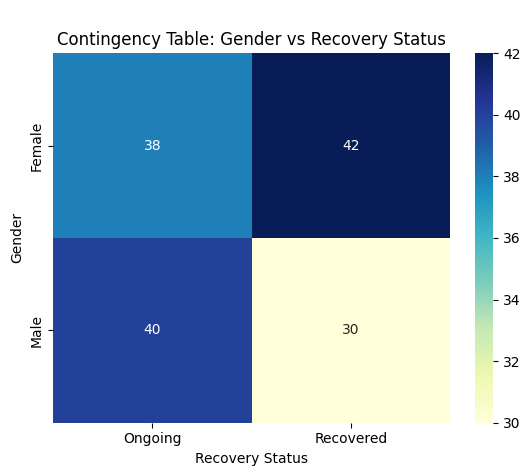

In [58]:
# Chi‑Square Test 
# Interpretation 
# Null Hypothesis (H₀): Gender and Recovery_Status are independent.
# Alternative Hypothesis (H₁): There is an association between Gender and Recovery_Status.
# Decision Rule: If p < 0.05, reject H₀.
# If significant, you can say “Recovery outcomes differ by gender in the ER dataset.”
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Hospital Mangement System.csv")

# Drop rows with missing values in Gender or Recovery_Status
df = df[df['Gender'].notnull() & df['Recovery_Status'].notnull()]

# Create contingency table: rows = Gender, columns = Recovery_Status
contingency_table = pd.crosstab(df['Gender'], df['Recovery_Status'])

print("Contingency Table:")
print(contingency_table)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Output results
print(f"\nChi-square Statistic:{chi2:.3f}")
print("Degrees of Freedom:", dof)
print(f"P-value:{p:.3f}")

# Significance level
alpha = 0.05  # 5% significance level

# Decision rule
if p < alpha:
    print("\nResult: Significant association between Gender and Recovery Status (Reject H₀)")
else:
    print("\nResult: No significant association between Gender and Recovery Status(Fail to reject H₀)")

# Heatmap visualization
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title("\nContingency Table: Gender vs Recovery Status")
plt.xlabel("Recovery Status")
plt.ylabel("Gender")
plt.show()



T-Statistic: -0.433
P-Value: 0.666
Fail to reject H₀: No significant difference in Charges between groups.


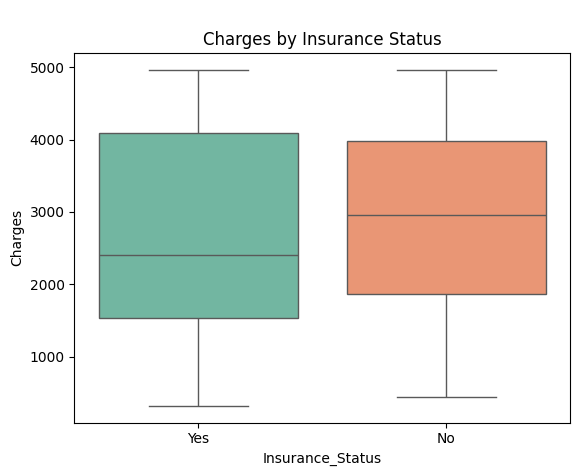

In [57]:
#  T Test (Charges: Insured vs Not Insured)
# Goal: Test if insured patients pay significantly different charges compared to uninsured patients.
# Interpretation
# H₀: Mean charges are equal for insured and uninsured patients.
# H₁: Mean charges differ between insured and uninsured patients.
# If p < 0.05, you conclude insurance status significantly affects charges.
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Separate charges based on insurance status
insured = df[df['Insurance_Status'].str.lower() == 'yes']['Charges']
not_insured = df[df['Insurance_Status'].str.lower() == 'no']['Charges']

# Perform Independent Sample T-Test
t_stat, p_value = stats.ttest_ind(insured, not_insured)
print(f"T-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_value:.3f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Significant difference in Charges between Insured and Uninsured patients.")
else:
    print("Fail to reject H₀: No significant difference in Charges between groups.")

sns.boxplot(x='Insurance_Status', y='Charges', data=df, hue='Insurance_Status', palette='Set2', legend=False)
plt.title("\nCharges by Insurance Status")
plt.show()



--- One-Way ANOVA Results ---
F-statistic: 2.8127282067214145
p-value: 0.027597018071539362
Reject H₀: Mean Treatment Costs differ significantly across departments.


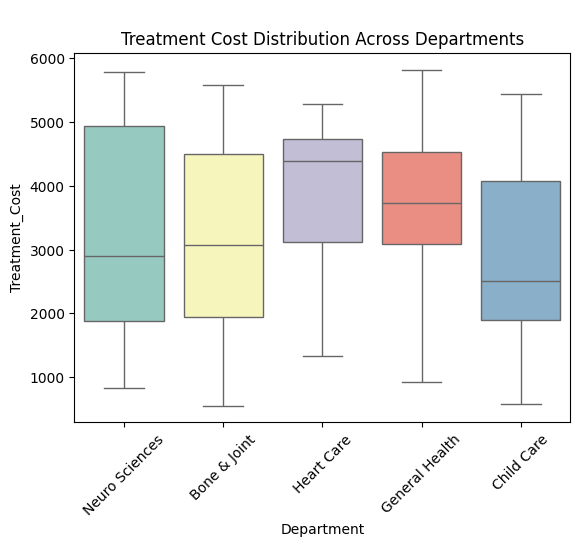

In [63]:
# ANOVA (Treatment Cost across Departments)
# Goal: Test if average treatment costs differ across departments.
# Interpretation
# H₀: Mean treatment costs are equal across all departments.
# H₁: At least one department has a different mean treatment cost.
# If p < 0.05, you conclude costs vary significantly by department.

from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
# Separate treatment costs by department
groups = [df[df['Department'] == dept]['Treatment_Cost'].dropna() 
          for dept in df['Department'].unique()]

# One-Way ANOVA test
f_stat, p_value = stats.f_oneway(*groups)

print("--- One-Way ANOVA Results ---")
print("F-statistic:", f_stat)
print("p-value:", p_value)

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Mean Treatment Costs differ significantly across departments.")
else:
    print("Fail to reject H₀: No significant difference in Treatment Costs between departments.")

sns.boxplot(x='Department', y='Treatment_Cost', data=df, hue='Department', palette='Set3', legend=False)
plt.title("\nTreatment Cost Distribution Across Departments")
plt.xticks(rotation=45)
plt.show()


----- Pearson Correlation Coefficients -----
Age vs Charges: 0.056
Visit_Duration vs Treatment_Cost: -0.063
Severity vs Readmission_Count: -0.092

----- Spearman Correlation Coefficients -----
Age vs Charges: 0.054
Severity vs Readmission_Count: -0.090


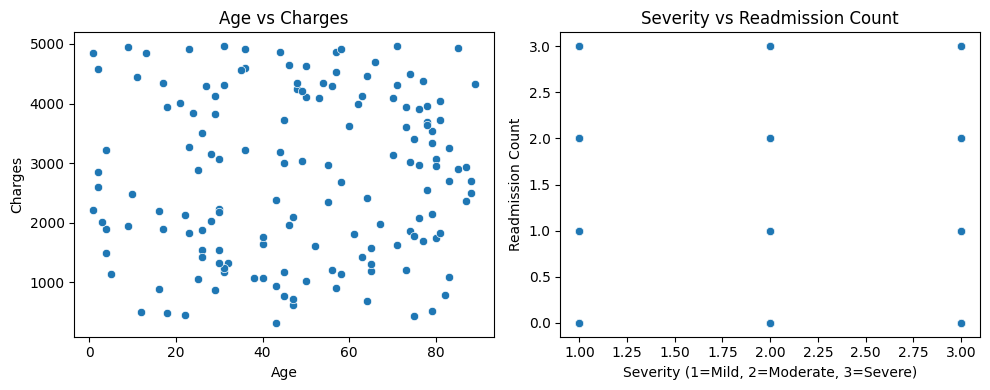


----- Pearson Correlation Matrix -----
                        Age   Charges  Visit_Duration  Treatment_Cost  \
Age                1.000000  0.056145        0.101488        0.018108   
Charges            0.056145  1.000000       -0.055837        0.980540   
Visit_Duration     0.101488 -0.055837        1.000000       -0.062936   
Treatment_Cost     0.018108  0.980540       -0.062936        1.000000   
Readmission_Count  0.029234 -0.104005        0.181372       -0.094384   
Severity_Num       0.192738 -0.038692        0.091640       -0.024685   

                   Readmission_Count  Severity_Num  
Age                         0.029234      0.192738  
Charges                    -0.104005     -0.038692  
Visit_Duration              0.181372      0.091640  
Treatment_Cost             -0.094384     -0.024685  
Readmission_Count           1.000000     -0.091714  
Severity_Num               -0.091714      1.000000  

----- Spearman Correlation Matrix -----
                        Age   Charge

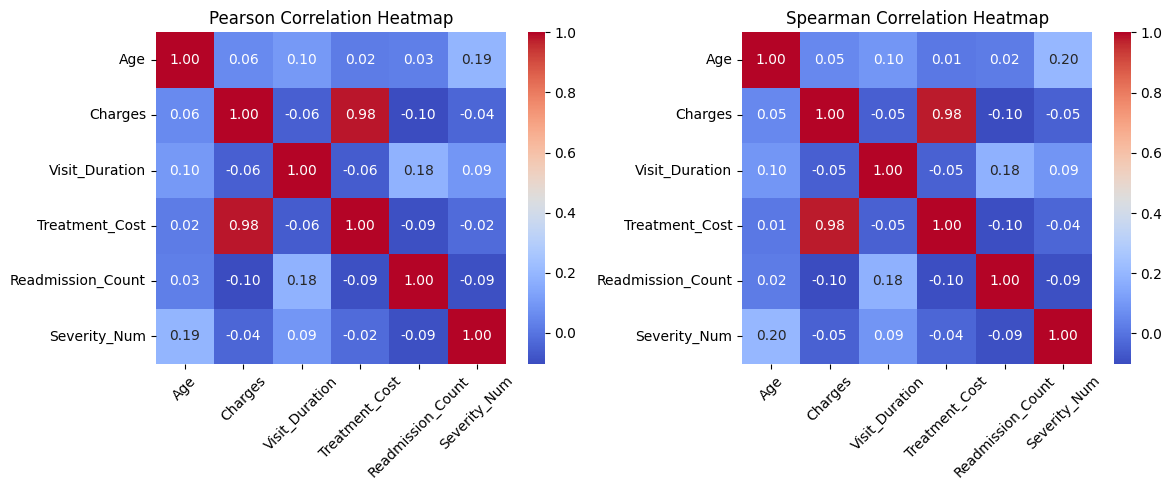

In [74]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Prepare Severity as Numeric (ordinal mapping) ---
severity_map = {"Mild": 1, "Moderate": 2, "Severe": 3}
df["Severity_Num"] = df["Patient_Condition_Severity"].map(severity_map)

# --- Step 2: Pearson Correlations ---
pearson_age_charges = df['Age'].corr(df['Charges'], method='pearson')
pearson_duration_cost = df['Visit_Duration'].corr(df['Treatment_Cost'], method='pearson')
pearson_severity_readmit = df['Severity_Num'].corr(df['Readmission_Count'], method='pearson')

print("----- Pearson Correlation Coefficients -----")
print(f"Age vs Charges: {pearson_age_charges:.3f}")
print(f"Visit_Duration vs Treatment_Cost: {pearson_duration_cost:.3f}")
print(f"Severity vs Readmission_Count: {pearson_severity_readmit:.3f}")

# --- Step 3: Spearman Correlations ---
spearman_age_charges = df['Age'].corr(df['Charges'], method='spearman')
spearman_severity_readmit = df['Severity_Num'].corr(df['Readmission_Count'], method='spearman')

print("\n----- Spearman Correlation Coefficients -----")
print(f"Age vs Charges: {spearman_age_charges:.3f}")
print(f"Severity vs Readmission_Count: {spearman_severity_readmit:.3f}")

# --- Step 4: Scatter Plots ---
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.scatterplot(x='Age', y='Charges', data=df)
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.subplot(1,2,2)
sns.scatterplot(x='Severity_Num', y='Readmission_Count', data=df)
plt.title("Severity vs Readmission Count")
plt.xlabel("Severity (1=Mild, 2=Moderate, 3=Severe)")
plt.ylabel("Readmission Count")

plt.tight_layout()
plt.show()

# --- Step 5: Correlation Matrices ---
pearson_matrix = df[['Age','Charges','Visit_Duration','Treatment_Cost','Readmission_Count','Severity_Num']].corr(method='pearson')
spearman_matrix = df[['Age','Charges','Visit_Duration','Treatment_Cost','Readmission_Count','Severity_Num']].corr(method='spearman')

print("\n----- Pearson Correlation Matrix -----")
print(pearson_matrix)

print("\n----- Spearman Correlation Matrix -----")
print(spearman_matrix)

# --- Step 6: Heatmaps ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(pearson_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.heatmap(spearman_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# supervised Learning (Classification)
# Goal: Predict patient outcomes (e.g., Recovery_Status or Readmission_Count > threshold). 
# Naïve Bayes → simple probabilistic baseline
# k‑NN → patient similarity based classification
# Decision Tree / Random Forest → interpretable rules + feature importance

In [ ]:
# Step 1: Preprocessing
# Target (y): Recovery_Status (Recovered / Not Recovered)
# Features (X): Age, Gender, Treatment_Cost, Visit_Duration, Insurance_Status, Readmission_Count
# Encode categorical variables, scale numeric features, and split into train/test.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Step 1: Handle missing values (example: Age, Charges)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Charges'] = df['Charges'].fillna(df['Charges'].median())

# Step 2: Encode categorical variables 
encoder = LabelEncoder()
df['Gender'] = encoder.fit_transform(df['Gender'])        # male=1, female=0
df['Insurance_Status'] = encoder.fit_transform(df['Insurance_Status'])  # yes=1, no=0
df['Recovery_Status'] = encoder.fit_transform(df['Recovery_Status'])    # recovered=1, not=0

# Step 3: Define features and target
X = df[['Age','Gender','Treatment_Cost','Visit_Duration','Insurance_Status','Readmission_Count']]
X = pd.get_dummies(X, drop_first=True)
y = df['Recovery_Status']

# Step 4: Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [127]:
# Model 1: Naïve Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score

# Initialize the model
gnb = GaussianNB()

# Train the model
gnb.fit(X_train, y_train)

# Predict on test data
y_pred_gnb = gnb.predict(X_test)

# Step 2: Compute performance metrics
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)
cm = confusion_matrix(y_test, y_pred_gnb)

print("-----Naïve Bayes-----")
print(f"Accuracy: {accuracy_gnb:.3f}")
print(f"Precision: {precision_gnb:.3f}")
print(f"Recall: {recall_gnb:.3f}")
print(f"F1-Score: {f1_gnb:.3f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gnb))


-----Naïve Bayes-----
Accuracy: 0.433
Precision: 0.222
Recall: 0.167
F1-Score: 0.190

Confusion Matrix:
 [[11  7]
 [10  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.61      0.56        18
           1       0.22      0.17      0.19        12

    accuracy                           0.43        30
   macro avg       0.37      0.39      0.38        30
weighted avg       0.40      0.43      0.41        30



-----k‑Nearest Neighbors (k‑NN)-----
Best value of k: 19
Accuracy: 0.633
Precision: 0.538
Recall: 0.583
F1-Score: 0.560

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.67      0.69        18
           1       0.54      0.58      0.56        12

    accuracy                           0.63        30
   macro avg       0.62      0.62      0.62        30
weighted avg       0.64      0.63      0.64        30



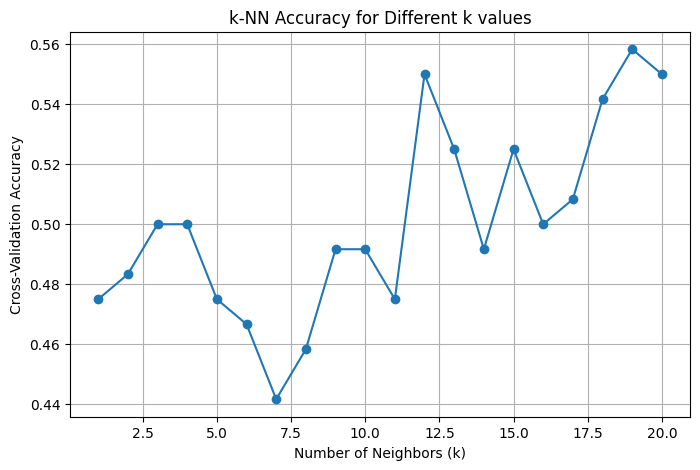

In [129]:
# Model 2: k‑Nearest Neighbors (k‑NN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Test different values of k
k_values = range(1, 21)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    
# Find best k
best_k = k_values[cv_scores.index(max(cv_scores))]
print("-----k‑Nearest Neighbors (k‑NN)-----")
print(f"Best value of k: {best_k}")

# Train the model with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

# Predict
y_pred_knn = knn_best.predict(X_test)

# Evaluate
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.3f}")
print(f"Precision: {precision_knn:.3f}")
print(f"Recall: {recall_knn:.3f}")
print(f"F1-Score: {f1_knn:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# Plot CV accuracy vs k
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.title('k-NN Accuracy for Different k values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True)
plt.show()


-----Decision Tree-----
Accuracy: 0.500
Precision: 0.412
Recall: 0.583
F1-Score: 0.483

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.44      0.52        18
           1       0.41      0.58      0.48        12

    accuracy                           0.50        30
   macro avg       0.51      0.51      0.50        30
weighted avg       0.53      0.50      0.50        30



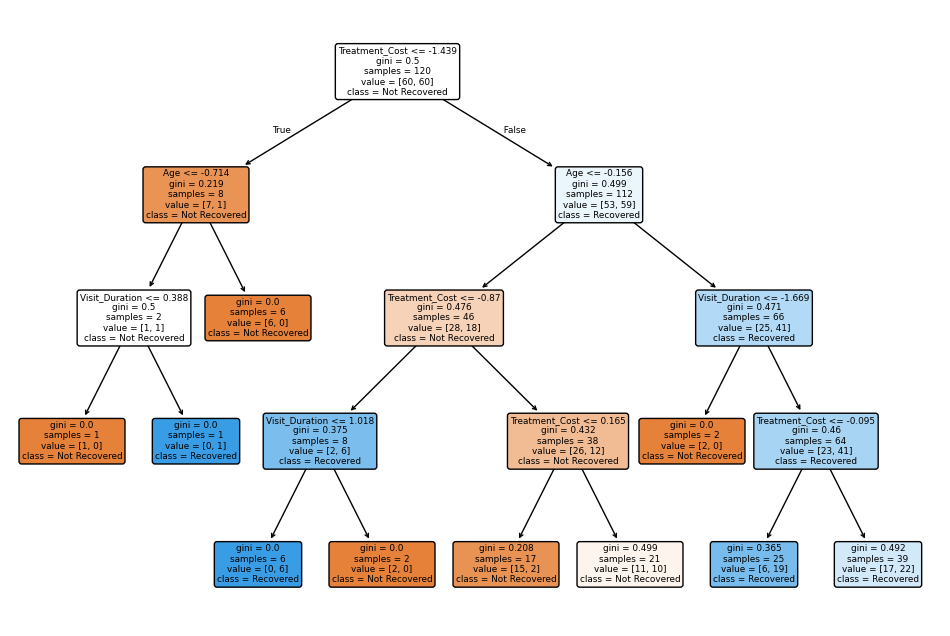


Decision Tree Rules:
 |--- Treatment_Cost <= -1.44
|   |--- Age <= -0.71
|   |   |--- Visit_Duration <= 0.39
|   |   |   |--- class: 0
|   |   |--- Visit_Duration >  0.39
|   |   |   |--- class: 1
|   |--- Age >  -0.71
|   |   |--- class: 0
|--- Treatment_Cost >  -1.44
|   |--- Age <= -0.16
|   |   |--- Treatment_Cost <= -0.87
|   |   |   |--- Visit_Duration <= 1.02
|   |   |   |   |--- class: 1
|   |   |   |--- Visit_Duration >  1.02
|   |   |   |   |--- class: 0
|   |   |--- Treatment_Cost >  -0.87
|   |   |   |--- Treatment_Cost <= 0.17
|   |   |   |   |--- class: 0
|   |   |   |--- Treatment_Cost >  0.17
|   |   |   |   |--- class: 0
|   |--- Age >  -0.16
|   |   |--- Visit_Duration <= -1.67
|   |   |   |--- class: 0
|   |   |--- Visit_Duration >  -1.67
|   |   |   |--- Treatment_Cost <= -0.10
|   |   |   |   |--- class: 1
|   |   |   |--- Treatment_Cost >  -0.10
|   |   |   |   |--- class: 1



In [131]:
# Model 3: Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 1: Initialize and train
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Step 2: Predict
y_pred_dt = dt.predict(X_test)

# Step 3: Metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("-----Decision Tree-----")
print(f"Accuracy: {accuracy_dt:.3f}")
print(f"Precision: {precision_dt:.3f}")
print(f"Recall: {recall_dt:.3f}")
print(f"F1-Score: {f1_dt:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Step 4: Visualize tree
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=list(X.columns), class_names=['Not Recovered','Recovered'], filled=True, rounded=True)
plt.show()

# Step 5: Extract rules (optional, exam-ready)
rules = export_text(dt, feature_names=list(X.columns))
print("\nDecision Tree Rules:\n", rules)


-----Random Forest Performance-----
Accuracy: 0.533
Precision: 0.400
Recall: 0.333
F1-Score: 0.364

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63        18
           1       0.40      0.33      0.36        12

    accuracy                           0.53        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.52      0.53      0.52        30



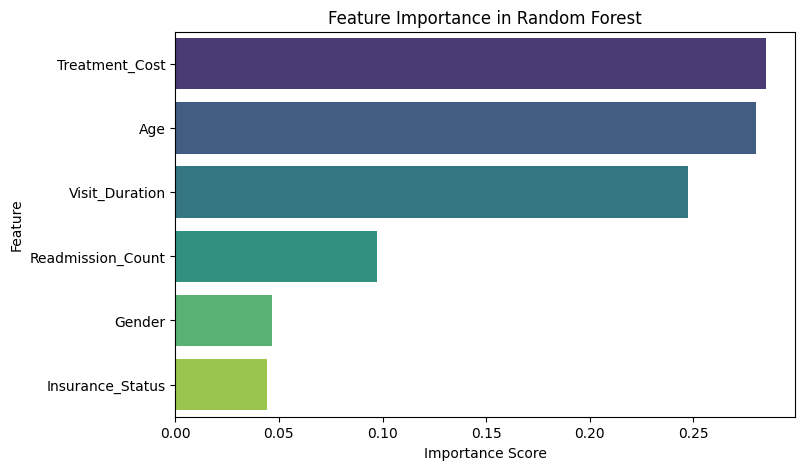

In [132]:
# Model 4: Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Initialize and train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 2: Predict
y_pred_rf = rf.predict(X_test)

# Step 3: Compute evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("-----Random Forest Performance-----")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-Score: {f1_rf:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Step 4: Feature importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize feature importance (fixed palette warning)
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importances, palette='viridis', legend=False)
plt.title('Feature Importance in Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


In [134]:
# comparison table for all supervised models
import pandas as pd

comparison = pd.DataFrame({'Model': ['Naïve Bayes', 'k-NN', 'Decision Tree', 'Random Forest'],
                           'Accuracy': [accuracy_gnb, accuracy_knn, accuracy_dt, accuracy_rf],
                           'Precision': [precision_gnb, precision_knn, precision_dt, precision_rf],
                           'Recall': [recall_gnb, recall_knn, recall_dt, recall_rf],
                           'F1-Score': [f1_gnb, f1_knn, f1_dt, f1_rf]})

print("-----Model Comparison-----")
print(comparison)


-----Model Comparison-----
           Model  Accuracy  Precision    Recall  F1-Score
0    Naïve Bayes  0.433333   0.222222  0.166667  0.190476
1           k-NN  0.633333   0.538462  0.583333  0.560000
2  Decision Tree  0.500000   0.411765  0.583333  0.482759
3  Random Forest  0.533333   0.400000  0.333333  0.363636


In [130]:
# Model5: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize and train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr.predict(X_test)

#Compute R² and RMSE
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("-----Linear Regression Model-----")
print(f"R² (Coefficient of Determination): {r2_lr:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse_lr:.3f}")

#Display intercept and coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
print(f"Intercept: {lr.intercept_:.3f}")
print(coefficients)


-----Linear Regression Model-----
R² (Coefficient of Determination): -0.108
RMSE (Root Mean Squared Error): 0.516
Intercept: 0.491
             Feature  Coefficient
0                Age     0.076174
1             Gender    -0.067500
2     Treatment_Cost     0.041139
3     Visit_Duration     0.021841
4   Insurance_Status     0.006012
5  Readmission_Count     0.000430
